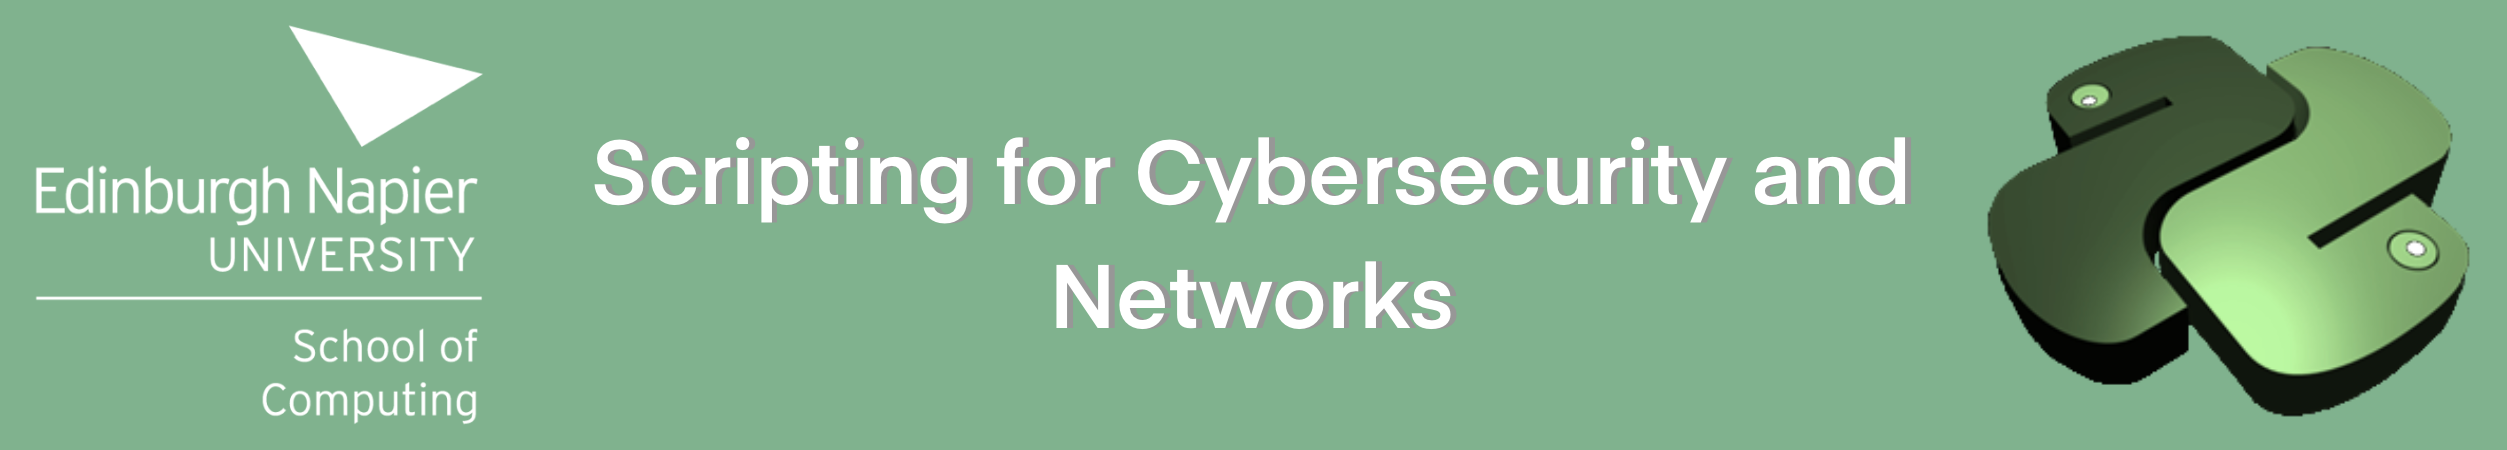

# Lab 04: Exception Handling, system interaction with sys, os and os.path, computer networking with sockets


---
In this lab you will practice exception (error) handling in Python.   
You will also use several important standard modules: sys to interact with the Python interpreter and use command-line arguments at runtime, os and its sub-library os.path to interact with the host operating system e.g. to work with external files and paths.    

You already practised reading from text files in lab 3; in this lab, you will extend your skills in working with files to include writing to files. 
You will use some of the above concepts to expand the password cracker script.    

Finally, you will learn how to create sockets in Python and make them communicate with each other – this should be a fun bit of computer networking.   

This is another long lab, you should <span style='color :red' >**skip any optional extensions initially and come back to them as your homework.**</span>

* Exercises 1-6 go with L4.4 Exception Handling and L4.5 Assertions and unit tests.
* Exercise 7 practices writing output to a file.
* Exercises 8-14 go with L4.1 OS, SYS, subprocess.   
* Exercise 15 extends the password cracker case study from lab 03 
* Exercises 16 and 17 are optional and extend Exercise 10
* The separate Lab4_sockets.ipynb contains exercises that go with L4.3 Sockets 

---

### ESSENTIAL READING
---
You should read up on Exceptions - it is up to you whether you choose to do this before, during, or after these exercises!   
My favourite page for this is https://realpython.com/python-exceptions/.   
Make sure you also understand **else, finally, and assert** - the exercises below barely touch these important concepts which will make you an error handling pro.   
Also note that when you print exceptions, this should be to std.err - this is shown on the lecture slides, but not yet incorporated into the exercises below.

### OPTIONAL READING
---
For the socket server and client, the lecture and lab sheet should give you pretty much everything you need. If you want to extend your knowledge in this area and play around with more advanced sockets, I recommend https://realpython.com/python-sockets/. The first four subsections, including Echo Client and Server, are the introductory bits that are covered by the lab exercises below, after that it gets more advanced.



---

## 1. External Data – User Input Exceptions
---


In lab03, Section 5, we had some code that asks the user to supply two inputs which are then added.

Your code from lab03 should look something like shown below.    
Run the code, entering 'knight' as the first number and your favourite number as the second. 

In [3]:
reply1 = input("Please enter a number: ")
reply2 = input("Please enter a 2nd number: ")
total = float(reply1) + float(reply2)
print(f"Sum = {total}")

ValueError: could not convert string to float: "'knight'"

You will get an error message.

Q1.1: What specific type of Exception is raised?

---

The Traceback shows exactly where the run-time error occurred. The type of error and the error itself are shown on the last line; in this case a **ValueError.**  

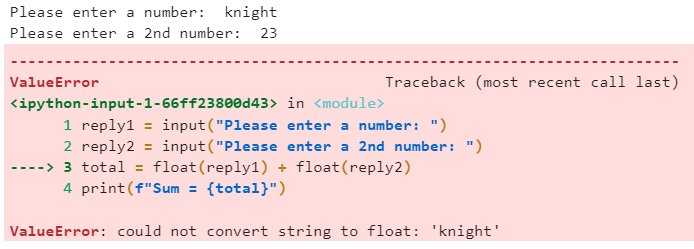

**Trapping the exception**

Exception Handling in Python is done using the "try/except" construct. 
In this example, we want to check for a **ValueError** and carry out a different action if it has occurred - we'll print a tailored error message for the user in this example.    

This could be done like the code shown below.

* If given two numbers it should run exactly as before;
* If given a string that cannot be converted to a float, it should print the error message.

In [6]:
# Code wrapped in try/except blocks

try:
    reply1 = input("Please enter a number: ")
    reply2 = input("Please enter a 2nd number: ")
    total = float(reply1) + float(reply2)
    print(f"Sum = {total}")
except ValueError:
    print("Please supply numbers")

Please supply numbers


So here we have "wrapped" all of the code in a ```try:``` block, and then added an ```except:``` block to handle the Exception.  
When you run the code now, with 'knight' as one input and your favourite number as the other, Python no longer shows a Traceback. The little script now finishes "properly", printing a planned message for the user. When you enter two numbers, they are added up as before, as the code in the try: block completes successfully.

---

It is good practice to print any messages to sys.stderr. Normally, this is just the screen, but in a larger application all error handling outputs can then easily be directed to a single log file by redefining stderr. For this we need the sys module, which will be introduced in more detail later in this lab.

Here is the same code using sys.stderr:

In [7]:
# Code wrapped in try/except blocks
# using sys.stderr for output
import sys

try:
    reply1 = input("Please enter a number: ")
    reply2 = input("Please enter a 2nd number: ")
    total = float(reply1) + float(reply2)
    print(f"Sum = {total}")
except ValueError:
    print("Please supply numbers", file=sys.stderr)

Please supply numbers


Run this code. 

Q1.2: How does the output change when you enter a string and a number?


---


## 2. Optional Challenges
---

   
Let's see what happens if we don't convert the input to float.

The code below is the same as before, except without float(). Run this three times:
- with Hello and World as inputs
- with 6 and 7.8 as inputs
- with a number and a string as inputs

Note what happens in each case.


In [11]:
# Code wrapped in try/except blocks
# using sys.stderr for output
# without converting the input
import sys

try:
    reply1 = input("Please enter a number: ")
    reply2 = input("Please enter a 2nd number: ")
    total = reply1 + reply2
    print(f"Sum = {total}")
except ValueError:
    print("Please supply numbers", file=sys.stderr)

Sum = 79


---

**Challenge A**: Change the copy of the code below so that:
- it correctly adds up the numbers if numbers are given
- concatenates strings if two strings are given
- prints an error message if a number and a string are given

In [21]:
#Change this copy of teh code so that it solves challenge A
import sys

reply1 = input("Please enter a number or string: ")
reply2 = input("Please enter a 2nd number or string: ")

try:
    number1 = float(reply1)
    first_is_number = True
except ValueError:
    first_is_number = False

try:
    number2 = float(reply2)
    second_is_number = True
except ValueError:
    second_is_number = False

if first_is_number and second_is_number:
    print(f"Sum = {number1 + number2}")
elif not first_is_number and not second_is_number:
    print(f"Combined = {reply1 + reply2}")
else:
    print("Please enter either two numbers or two strings", file=sys.stderr)

Please enter either two numbers or two strings


---

**Challenge B**: Make a copy of your solution for challenge A, and change it so that if a number and string are given, the script asks for input again after printing the error message. 

To achieve this, you will need to wrap the try: and except: blocks in a **while loop** - the rest is up to you. 


In [ ]:
# copy your solution from A, then modify
import sys

while True:
    reply1 = input("Please enter a number or string: ")
    reply2 = input("Please enter a 2nd number or string: ")

    try:
        number1 = float(reply1)
        first_is_number = True
    except ValueError:
        first_is_number = False

    try:
        number2 = float(reply2)
        second_is_number = True
    except ValueError:
        second_is_number = False

    if first_is_number and second_is_number:
        print(f"Sum = {number1 + number2}")
        break
    elif not first_is_number and not second_is_number:
        print(f"Combined = {reply1 + reply2}")
        break
    else:
        print("Please enter either two numbers or two strings", file=sys.stderr)

Please enter either two numbers or two strings
Please enter either two numbers or two strings


---

## 3. Another try/except example - using general Exceptions
---

The code below is from Lab 3 Section 10. We used string.split() to break up each line of our common passwords file into individual base passwords and password variants, and store them in a Tuple. In lab 3, we later added an extra argument, maxsplit=1, to line.split(), because the code as shown here raises an exception when dealing with the fourth line in the file.

***Check you have saved common.txt in the same directory as the lab, so the file can be opened.***

Then run the code below.

In [1]:
with open("common.txt") as passwords:
    for line in passwords:
        (passwd, variant) = line.split(", ")
        print(f"{passwd=}, {variant=}")

passwd='qwerty', variant='qwerty1\n'
passwd='password', variant='password1\n'
passwd='default', variant='default1\n'


ValueError: too many values to unpack (expected 2, got 3)

From the Traceback, you can see that the Exception occurs in line 3 of the code.

Now we can group the code which caused the error and the code directly after it together in a try: block, and add an except: block to handle the exception. In this case, we'll print that the line isn't of the expected format.


In [2]:
with open("common.txt") as passwords:
    for line in passwords:
        try:
            (passwd, variant) = line.split(", ")
            print(f"Password: {passwd}, Variant(s): {variant}")
        except Exception as err:
            print("Line does not conform to expected format")

Password: qwerty, Variant(s): qwerty1

Password: password, Variant(s): password1

Password: default, Variant(s): default1

Line does not conform to expected format


---

This stopped the crash and the Traceback, but the line that causes the problem is not printed.  
We can fix this by adding another print statement in the except: block.  
Also, it may be useful to print the details of the Exception.

The code below does this - run it to see what happens.

In [6]:
import sys

with open("common.txt") as passwords:
    for line in passwords:
        try:
            (passwd, variant) = line.split(", ")
            print(f"Password: {passwd}, Variant(s): {variant}")
        except Exception as err:
            print(f"{line=}", file=sys.stderr)
            print("Line does not conform to expected format", file=sys.stderr)
            print(f"Exception ({err.__class__.__name__}): {err}", file=sys.stderr)

Password: qwerty, Variant(s): qwerty1

Password: password, Variant(s): password1

Password: default, Variant(s): default1



line='123, 12345, 123456'
Line does not conform to expected format
Exception (ValueError): too many values to unpack (expected 2, got 3)


---

In this example, we have used the most general ```Exception``` instead of being specific.

To check this code with pylint, it has also been saved as a script called files.py, which is included in the lab zip file. 

Do the check by running the next cell.


In [5]:
!pylint files.py

************* Module files
files.py:1:0: C0114: Missing module docstring (missing-module-docstring)
files.py:3:5: W1514: Using open without explicitly specifying an encoding (unspecified-encoding)
files.py:8:15: W0718: Catching too general exception Exception (broad-exception-caught)

-----------------------------------
Your code has been rated at 7.00/10



You should find that pylint gives a "W0703" warning:



This warning is raised because we lose information about the error itself by not being specific about the exception type, and "hiding the error". 

We have already mitigated the generality a bit by printing details of the Exception instead of using a completely "bare" Except like ```except:```.  
For such a bare except pylint would report **W0702: No exception type(s) specified (bare-except)**, and would penalise the score more than for W0703.

Here, we should use ```ValueError``` to catch the specific error we are expecting and want to deal with. 

In [ ]:
import sys

with open("common.txt") as passwords:
    for line in passwords:
        try:
            (passwd, variant) = line.split(", ")
            print(f"Password: {passwd}, Variant(s): {variant}")
        except ValueError:
            print(f"{line=}", file=sys.stderr)
            print("Line does not conform to expected format", file=sys.stderr)

---

**Good Practice**   
**Use specific exceptions wherever possible** – refer to the hierarchy of exceptions at https://docs.python.org/3/library/exceptions.html. The hierarchy includes base classes and classes, some of which have subclasses. Consider using classes or base classes to group some very specific exceptions together. For example, OSError includes the subclasses FieNotFoundError, FileExistsError, PermissionError and many more.   

It is ok to use a general "except Exception" to *supplement* specific exceptions, as a catch-all. If using this, you should use the format "except Exception as err:", as we did above, and then log or print err to help with debugging and code review.

---


Applying these ideas together means using several ```except:``` blocks after a single ```try:```. 

Always handle the most specific exceptions first. 

Applying this idea to this example, we could write:

In [ ]:
import sys

with open("common.txt") as passwords:
    for line in passwords:
        try:
            (passwd, variant) = line.split(", ")
            print(f"Password: {passwd}, Variant(s): {variant}")
        except ValueError:
            print(f"{line=}", file=sys.stderr)
            print("Line does not conform to expected format", file=sys.stderr)
        except Exception as err:
            print(f"Exception ({err.__class__.__name__}): {err}", file=sys.stderr)

---

In the cell below, the two except blocks have been swapped. Run this and compare the output with the previous.

In [ ]:
import sys

with open("common.txt") as passwords:
    for line in passwords:
        try:
            (passwd, variant) = line.split(", ")
            print(f"Password: {passwd}, Variant(s): {variant}")
        except Exception as err:
            print(f"Exception({err.__class__.__name__}): {err}", file=sys.stderr)
        except ValueError:
            print(f"{line=}", file=sys.stderr)
            print("Line does not conform to expected format", file=sys.stderr)

---

## 4. File Handling Exceptions
---


If you are working with an external file, typical problems can be that the filename is given incorrectly or the file is in a different location than expected. Then, if we try to open the file, the program will crash, and an Exception will be raised.   

Our code from Section 3 opens a file called "common.txt". To see what happens if that file doesn't exist, we have changed **common.txt** to **common1.txt** in the copy of the code below. 

Run this cell and see what happens.


In [ ]:
import sys

with open("common1.txt") as passwords:
    for line in passwords:
        try:
            (passwd, variant) = line.split(", ")
            print(f"Password: {passwd}, Variant(s): {variant}")
        except ValueError:
            print(f"{line=}", file=sys.stderr)
            print("Line does not conform to expected format", file=sys.stderr)
        except Exception as err:
            print(f"Exception({err.__class__.__name__}): {err}", file=sys.stderr)

---

Q4.1 Why do the existing except: blocks not deal with this problem?

---
This particular Exception occurs **before** we even reach the for loop in which the existing try/except blocks are located. 


In the copy of the code below, add a second layer of Exception handling to wrap around the entire **with open()..** block, which catches the **FileNotFoundError** and gives the user a message ‘Cannot open or find common1.txt’. Of course "common1.txt" should actually be a placeholder, which always prints the name of the file that we are attempting to open - use an f-string to allow for this.

Keep the existing exception handling where it is - it is good practice to catch exceptions as close to the point they're thrown as possible. This makes the code easier to read and avoids catching unrelated exceptions of the same type.   
 

Run and test your code until it works as described.  
- Test it with another filename, like "Friday.txt", to check that this filename is printed in the error message. 
- Test it also with "common.txt", when it should work just as before.

In [ ]:
# Copy of the above code
# Task: add code to handle FileNotFoundError
import sys

with open("common1.txt") as passwords:
    for line in passwords:
        try:
            (passwd, variant) = line.split(", ")
            print(f"Password: {passwd}, Variant(s): {variant}")
        except ValueError:
            print(f"{line=}", file=sys.stderr)
            print("Line does not conform to expected format", file=sys.stderr)
        except Exception as err:
            print(f"Exception({err.__class__.__name__}): {err}", file=sys.stderr)

Check your answer against the published answers when they are released. The code in Exercise 5 below also contains the same exception handling.

---

## 5. Reading common.txt into a list
---

The code we worked with in exercises 3 and 4 above uses a **tuple** for unpacking the password and its variant. This originated in Lab 3 exercise 10, where we learnt that a tuple is a good collection object to use if the data being read are in a fixed format. However, we found that this raised an exception when the data format varies - in this case, when there is more than one variant. 

We solved this in Exercise 3 above by effectively skipping any line in common.txt that has two variants (printing error messages instead), allowing the rest of the file to be processed. 

However, if we are interested in all common passwords and variants, for example, for using in a dictionary attack, skipping over the unusual lines in common.txt is not a good idea.  
So how can we change our script so that each line can contain *several* variants?   
Let's try using a List object to collect the data from the file instead of a tuple:

In [ ]:
import sys

passwds = []
my_file = "common.txt"
try:
    with open(my_file, "r") as passwords:
        for line in passwords:
            try:
                passwds.append(line.split(", "))
            except ValueError:
                print(f"{line=}", file=sys.stderr)
                print("Line does not conform to expected format", file=sys.stderr)
            except Exception as err:
                print(f"Exception({err.__class__.__name__}): {err}", file=sys.stderr)
    print(f"{passwds=}")
except FileNotFoundError:
    print(f"Cannot open or find {my_file}", file=sys.stderr)

---

Q5.1: What does the **passwds[ ]** list contain?

Q5.2: Why does the last element of almost every sub-list end with "\n"?

Q5.3: Why does the last element of the last sub-list *not* end with "\n"?

---

With this changed code, a ValueError can no longer occur - *line* will always be a string, which the *.split()* method can be applied to, and the resulting object can always be appended to passwds.  
So we can remove the except: block.  
We'll keep the general Exception in case of any unforeseen issues.  

In [ ]:
import sys

passwds = []
my_file = "common.txt"
try:
    with open(my_file, "r") as passwords:
        for line in passwords:
            try:
                passwds.append(line.split(", "))
            except Exception as err:
                print(f"Exception({err.__class__.__name__}): {err}", file=sys.stderr)
    print(f"{passwds=}")
except FileNotFoundError:
    print(f"Cannot open or find {my_file}", file=sys.stderr)

---

## 6. Chomping strings
---

The **"\n"** we noticed in questions 5.2 and 5.3 is the newline character.  
We can easily remove this from the end of the line before we split it using the **.strip()** string method, which also removes any whitespace.    
This is sometimes called chomping a string.

Here is an example:

In [ ]:
# run this code
chomp = "Pesky newline char\n"
chomp

If you use print(), the *\n* is interpreted:

In [ ]:
print(chomp)

If you look at the output from the cell above very carefully you can see the extra new line caused by the newline character.    

The .strip() method gets rid of the newline character - it "chomps" the string.

Run the next two cells and compare the outputs with the previous cells.

In [ ]:
chomp.strip()

In [ ]:
print(chomp.strip())

---

Modify the copy of the Exercise 5 code below, to use ```.strip()``` to chomp each line before appending it to the list.

In [ ]:
import sys

passwds = []
my_file = "common.txt"
try:
    with open(my_file, "r") as passwords:
        for line in passwords:
            try:
                passwds.append(line.split(", "))
            except Exception as err:
                print(f"Exception({err.__class__.__name__}): {err}", file=sys.stderr)
    print(f"{passwds=}")
except FileNotFoundError:
    print(f"Cannot open or find {my_file}", file=sys.stderr)

The output should now look like this:



---

There are various ways you could have implemented this task. The most elegant solution is to repace line 9 with:
~~~python
         passwds.append(line.strip().split(", "))
~~~

Q6.1: Why is the .strip() method applied before .split()?

Q6.2: Why is this preferable to adding a separate line?

---

## 7. External Data - Writing Data to Files
---

As we have seen before, the **open()** function opens a file and returns a file object or file stream. The built in **file** object contains the basic file handling methods to read data from files, such as read(). It also has functions to write data to files. 

Run the code below, then do the quiz below.  
Hint: Use Windows Explorer for the third question, or hover the mouse over a file in the directory listing in JupyterLab.

In [ ]:
my_file = open("outfile.txt", "w")

---

In [ ]:
import quiz_lab04
quiz_lab04.section_seven()

---

Now that the file is open for writing, we can write to the file using the standard **print()** function. 
print() writes to stdout by default, but it has an optional **file** argument which we can use to write to a file. We already used this argument in the print statements in Exercises 1-6 above, with sys.stderr. Here we use it with a file stream that represents a file open for writing.

For example:

In [ ]:
# print "Good morning", output redirected to my_file 
# my_file needs to be a file stream, opened in write or append mode
print("Good morning", file=my_file)

Of course there are also several explicit methods available for writing to a file stream.  
Check which ones using \<TAB\>.

&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;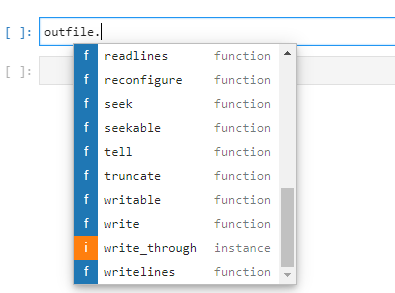

---

Q7.1: Which methods might be useful to write data to the file?

---

Let's try the .write() method first:

In [ ]:
# run this code
my_file.write("test line1\n")
my_file.write("test line2\n")

---

Q7.2: Check the contents of the file. Have the lines been written?

Q7.3: When you ran the code, the output was 11. Why?

---

The lines have not been written to the file yet - the file still appears empty.   
This is because the data is held in a buffer until the buffer is flushed or the file closed.   

Let's close the file stream:

In [ ]:
my_file.close()

---

Q7.4: Check the contents of the file. Have the lines been written now?

---

Open the file again in write mode, and write the following text to it. Each should appear on a new line in the file:

~~~python
test line3
test line4
~~~

Close the file and check the contents.   

In [ ]:
# write your code here


---

Q7.5: Check the contents of the file. How many lines does it contain now?

---

The file "w" write mode clears the file of its old contents if the file exists already. This is known as **clobbering** a file.  

To **append** to a file, keeping the existing contents, open it using append mode; **mode="a"**.   

Try:

In [ ]:
my_file = open("outfile.txt", "a")
my_file.write("test line5\n")
my_file.write("test line6\n")
my_file.close()

---

Check the contents of the file. It should now look like this:

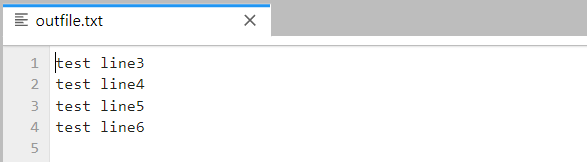

---

We have seen that closing the file "flushes" the buffer contents and writes the content to the file itself.  
If you have a lot to write to a file, you may want to flush it regularly to make sure no contents are lost if the script or computer crashes. However, it would be awkward to close the file and re-open it all the time. 

That's why there is a ```.flush()``` method to flush the outputs from the buffer to the file, without closing it. 

For example:

In [ ]:
my_file = open("outfile.txt", "a")
my_file.write("test line7\n")
my_file.flush()

Check the file contents. You should find that test line7 has been written to the file.

We can check if a file stream is closed using the .closed attribute:

In [ ]:
my_file.closed

The file is still open.  Close it before moving on:

In [ ]:
my_file.close()

Check again if the file stream is closed - it should be.

You could also use ```with open``` for writing to a file, and this is good practice as it automatically tidies up and closes the file when you're done.

---

## 8. The os module – working with the file system and file paths
---

So far, when opening external files using **open()**, we assumed the file we were reading from was in the same directory as the lab sheet we were working on.   

But what if the file is in a different directory?    
We could of course specify the filename using the whole path, e.g.
~~~
"C:\Users\Petra\CSN08114\common.txt" 
~~~
We already saw this very briefly in the quiz in exercise 7 above.

BUT…using a path like this would only work in Windows, and would introduce a dependency on the operating system.  
Python itself is deliberately operating system independent, so this is not a good idea.    

To solve this problem, we can **use the Python module os**.  
This module is used to interact with the underlying File System and **keep the code operating system independent** as much as possible. 


---

Import the os module first:

In [ ]:
import os

Now you can use \<TAB\> to see the available functions, variables ("instances") and sub-modules:

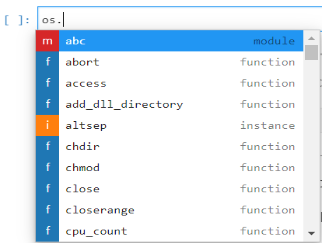

Use the up and down arrow keys to scroll through the list, and hit enter to select the function you want to use.   

Use the below code cell to try **os.\<TAB\>** yourself:

In [ ]:
os.

---

Scroll through the popup from os.\<TAB\> to do the short quiz below.

In [ ]:
import quiz_lab04
quiz_lab04.section_eight()

---

*Check the current working directory* using the ```os.getcwd()``` function. (The result will probably be the path to where you have saved this lab).


In [ ]:
# Get current working dir
os.getcwd()

If you are on Windows, you will notice that the path uses ```\\``` instead of ```\``` to separate directories and subdirectories. This is because in Python, the backslash needs to be "escaped" with another backslash. 

*List the files in the current working directory* with ```os.listdir()```:

In [ ]:
# List files and folders in current working dir
os.listdir()

Use the ```os.chdir()``` function to *change to another directory*.

(for the example below to work, make sure that C:\temp exists, or replace with another directory. Remember to escape backslashes with another backslash)

In [ ]:
# Change dir to C:\temp
os.chdir("C:\\temp")

We can declare any string as a **"raw string"** by prefixing it with ```r```. Then we don't need to escape the backslashes:

In [ ]:
# Change dir to C:\temp, using a raw string
os.chdir(r"C:\temp")

Check the dir has been changed:

In [ ]:
# Confirm working dir has been changed 
os.getcwd()

Finally, make sure to change the directory back to lab04:

In [ ]:
# change back to the dir where lab 4 is
os.chdir("<path_to_lab04>")  

---

## 9. Platform Independent variables
---

The os module also has some platform independent variables which are really useful for creating portable code that works on different operating systems. For example:
* os.curdir 
* os.sep 
* os.linesep

Note that these are **variables**, not functions, and therefore do not have any brackets.

Run the cells below to check what these variables represent. The answers you get will depend on your operating system.

In [ ]:
os.curdir

In [ ]:
os.sep

In [ ]:
os.linesep

In [ ]:
os.name

---

To finish our quick look at the os module, here is a small quiz.  
Looking back over the previous outputs should give you most of the answers. 

In [ ]:
# experiment here 

In [ ]:
import quiz_lab04
quiz_lab04.section_nine()

---

## 10. File System Interaction – The os.path sub-module
---

The **os.path** module is a sub-module within os. You can import it on its own if you don't need the rest of the os module.  
If you import os, os.path is automatically included.  

os.path is used to *manipulate directory and file paths of the underlying file system*. As with os, scripts written with os.path will be more portable across different platforms.   

As an example, let's use the directory listing returned from os.listdir(), and iterate over the files to do something with each file using the os.path module functions.

Run the cell below. 

In [ ]:
# Example 10a
# import os in case it is not imported yet. 
# includes os.path
import os

files = os.listdir()
for fname in files:
    path = os.path.join(os.path.curdir, fname)
    print(path)

Let's inspect this code in more detail.  
Make sure you can see line numbers - use *View > Show Line Numbers* to turn this on.

* Line 3: Our code uses functions from both os and os.path, so we import os, as it includes os.path.
* Line 5: This gets a list of all files and folders in the current directory and stores it in the files variable.
* Line 6: Now we can loop over all files and folders in files.
* Line 7: You already know that os.curdir is ```"."```, and represents the current directory. os.path.curdir is the same. Here we can use either, but when you have only imported os.path, only os.path.curdir would be available.  
os.path.join() is used to join partial file paths together. In the join, it automatically uses the correct separation character for the operating system, so in Windows it uses a backslash, while in Linux it would use a forward slash. 
* Line 8: Prints the path we have created in line 7. As os.path.curdir is a dot, the path we have printed here is the **relative path**, i.e. the path relative to the current directory. 

---

Often we need the *absolute path (or full path)* rather than the relative path. In Windows, this starts with the drive letter, e.g. 
~~~
C:\Users\petra\hello.py
~~~

The absolute path can be generated from the relative path using **os.path.abspath()**.   

The code below is the same as before, but prints the absolute paths:

In [ ]:
# Example 10b
import os

files = os.listdir()
for fname in files:
    path = os.path.join(os.path.curdir, fname)
    print(os.path.abspath(path))

---

Q10.1: Compare the outputs from the two cells above (Examples 10a and 10b) and describe the difference in your own words.

According to Wikipedia, "An **absolute path** points to the same location in a file system, regardless of the current working directory. To do that, it must include the root directory. 
A **relative path** starts from some given working directory, avoiding the need to provide the full absolute path. A filename can be considered as a relative path based at the current working directory. If the working directory is not the file's parent directory, a file not found error will result if the file is addressed by its name." (https://en.wikipedia.org/wiki/Path_(computing)#Absolute_and_relative_paths)

Q10.2: Explain in your own words why or when the absolute path may be needed. 

---

We can use fname itself as the argument to .abspath(). 

Thus we can shorten the code from Example 10b to:

In [ ]:
# Example 10c
import os

files = os.listdir()
for fname in files:
    print(os.path.abspath(fname))

Double check that Examples 10b and 10c give the same output.

---

We can check if a file or directory exists using **os.path.exists().**   
Try:

In [ ]:
os.path.exists(r"C:\temp")

---
Now try:

In [ ]:
os.path.exists(os.curdir)

Q10.3: Why will this always give True as the answer?

---

We can use the functions **os.path.isdir()**, and **os.path.isfile()** to check whether we are dealing with a file or a directory:  
~~~python
os.path.isfile(os.curdir)
os.path.isdir(os.curdir)
~~~


In [ ]:
# experiment here

Q10.4: Is os.curdir a file or directory? 

Q10.5: Is "C:\temp" a file or directory? 

Q10.6: Is "Lab4.ipynb" a file or directory? 

---

So far, we have used os.listdir() without an argument - and therefore got a listing of the current working directory.  
If you want a listing of a different directory, you can give its path as an argument to os.listdir(), for example:
```
os.listdir(r"C:\Users\petra")
```

This is often better than changing directory.

---

## 11. Joining and Splitting Paths
---

In os.path, there are also functions for splitting directory and filename.   

Try the following:


In [ ]:
# try this code 
import os.path
path1 = r"c:\temp\common.txt"
print(os.path.dirname(path1))
print(os.path.basename(path1))
print(os.path.split(path1))
print(os.path.splitext(path1))

---

Looking at the output, you can see that ```os.path.split()``` splits the path and the filename, returning a tuple that contais both parts. What if we want to separate out all the individual directories from the path?

For this, we can use the standard *string method .split()*. This method splits a string at every occurrence of the separator, which we pass as an argument.   

This example splits a person's name into the individual parts, the separator being the space character:

In [ ]:
"Susan Amy Elizabeth Bloggs".split(" ")

When working with file or directory paths, we use the operating system's path separator to split on.  
This is represented by the platform independent constant **os.sep** or **os.path.sep** (both are the same).

Example:

In [ ]:
import os.path
path1 = r"C:\temp\common.txt"
path1.split(os.path.sep)

---

Now do the small quiz below.

In [ ]:
import quiz_lab04
quiz_lab04.section_eleven()

---

## 12. Python System interaction: The sys module 
---

We have now had a good look at the **os** module, which allows us to interact with the computer's operating system through Python, using platform independent functions and constants. 

The **sys** standard module allows us to interact with the Python interpreter, and provides functions and variables for manipulating the Python runtime environment. The sys module's most important use is to handle arguments to pass to a whole script at runtime. This is done with **sys.argv**, which we explore in Exercise 13.

---



To get started, let's have a look at **sys.modules**. This variable stores all modules/packages that are currently installed and available for import in Python.   
This can be hundreds of modules, so the code below writes the output to the file modules.txt in the current directory.

In [ ]:
import sys

with open("modules.txt", "w") as f:
    f.write(str(sys.modules))

After you have run the code above, a new file modules.txt should have appeared in the directory listing on the left. Open it to have a look at the available modules/packages.

Then do the short quiz below:

In [ ]:
import quiz_lab04
quiz_lab04.section_twelve()

---

Because sys.modules is a dictionary, we can use **sys.modules.keys** to list just the modules available without all the additional information.

This still gives a lot of output, so after running the cell and having a look at the output, you can clear this output by right-clicking on the cell and choosing *Clear Outputs*.  
Alternatively, you can collapse the output by clicking on the blue bar to the left of the output. This will change it to an ellipsis (three dots). Clicking the dots expands the output again.

In [ ]:
sys.modules.keys()

---

## 13. Python Script Arguments with sys.argv
---

Many Python scripts are designed to be run from the command line. If you have an existing script, this is much faster than opening the script in an IDE to run it, or using other alternative methods.

But what if you need to pass information to the script at runtime? You'd want to just add this at the end of the command. 

In JupyterLabs, you would use **%run** or **!python** to run a script, or open a shell. In Windows, Linux or macOS you would use the relevant command line directly. (Screenshots showing this are further below).






If we are creating Python scripts which can be run from the command line, we may want to pass arguments to the script. Python stores these arguments in the sys.argv object.

**Create a script called args.py with the code below**. 
You can copy & paste the code from below to create the initial script and save

Remember how to create a .py file from Lab2?

* In the File Browser section of JuypterLab: Click the + and then Text File. Make sure you do this in the same directory as this notebook.A untitled.txt file should appear. Copy your above code into this file and rename it appropriately - make sure the extension is .py. 


<br>

In [ ]:
""" Manipulate Script Arguments - explore sys.argv
    Author: Petra L
    Modified: Oct 2021
    PEP8/pylint compliant
"""
import sys


def show_argv():
    """returns the arguments"""
    return sys.argv


def main():
    """calls show_argv() and handles printing"""
    args = show_argv()
    print("sys.argv is:")
    print(args)


# Standard boilerplate code to call main()
# to begin the program if run as a script.
if __name__ == "__main__":
    main()


---

Run the args.py script from the command line.    
Remember - you can do this in a Jupyter cell by putting a ! before the command: 



In [ ]:
# run script from command line:
!python args.py

Run again, passing some arguments with spaces such as hello world:

In [ ]:
# run script from command line:
!python args.py hello world

---

sys.argv is a list.  
The first element is always the script/module name.  
The additional elements are the arguments passed in by the user.

---

## 14. Adding functionality to the script
---

In the file args.py, add some code to main(), between lines 16 and 17, to check if the user has input any arguments. If not, print a usage message, such as: 

~~~
Usage: python args.py argument1 [argument2] [argument3] ...
~~~

Hint: use len() to check how may items are in sys.argv.

---

If the user has not added any command line arguments, there is no point continuing, so exit the script after the usage message by adding:
~~~python
sys.exit(1)
~~~

Now test the code:

In [ ]:
# test your added code - with no arguments
!python args.py

In [ ]:
# test that the message is NOT printed when an argument is given
!python args.py "Good morning"

---
Your outputs should look like this:

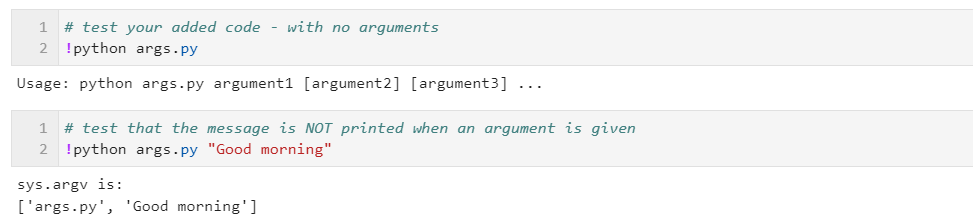

---

Change the code in main() to print only the arguments added by the user, and not the name of the function. 

Hint: sys.argv is a list, so you can slice it, e.g. sys.argv[:3] would give you the first three list elements - refer to Topic 2. 


In [ ]:
# Test that the name of the script is no longer printed
!python args.py "Good morning"
!python args.py hello world 

---

Finally, add some code to your script to print each individual argument on a different line, formatted as shown below.

Hints (see Topic 2): 
- iterate over the list
- use f-strings to format the output
- use .index() to get the "number". 

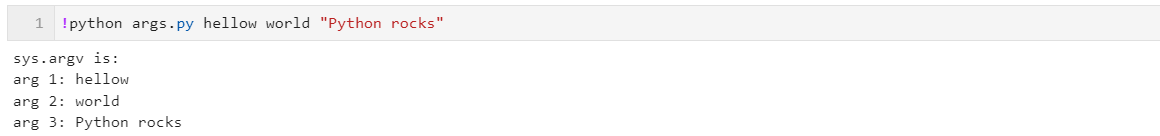

Test your script:

In [ ]:
!python args.py hellow world "Python rocks"

---

## 15. Return to the password cracker case study
---

**For this exercise it is assumed that you have completed the password cracker script and enhancements from Lab 3.**  
If you haven't completed this, you are strongly advised to work on that first. 

However, you can cheat if you really want - The script dict_crack_lab03_answers.py is part of the lab 3 solutions which you can download from moodle. 


---

The challenges below draw on several of the exercises you have completed earlier in this lab.

---

**Challenge A:**   
Create a copy of your solution for the password cracker from lab 3 and call it **dict_crack_lab04a.py**.

Complete the following tasks:
* Change the script so that the list of common passwords is read from an external file, rather than being defined in the script itself.   
Such files always contain one word per line.  
Remember that you will need to chomp the newline characters when reading from such a file.

* To test this, create a text file called **common3.txt** that contains the same common passwords as you had in the original script, one on each line.  
Rather than doing it manually, use Python - this will practice writing to files.   

* To complete this challenge, add exception handling to deal with the situation where the file cannot be found. 

In [ ]:
# To test this Challenge A
!python dict_crack_lab04a.py

---

**Challenge B:**   
Create a copy of **dict_crack_lab04a.py** saving it as **dict_crack_lab04b.py**.   

Inspired by Exercise 12 above, 
* Add code to the **dict_crack_lab4b.py** script so that the user can run the script from the command line, by adding the hash that is to be cracked as the command line argument.   
* As in the earlier exercise, also add a suitable usage message that is output if no hash is entered. 
* Remove the test cases currently in main() - instead, call the cracking function with the hash entered at runtime.

In [ ]:
# This is to test Challenge B with a hash
!python dict_crack_lab04b.py a67778b3dcc82bfaace0f8bc0061f20e
# This tests the usage message
!python dict_crack_lab04b.py 

---

**Challenge C: Evaluating the current script**

---

Think about your password cracking script, with enhancements A and B implemented.  
Answer the questions below. (Hover over the truncated answers to see the whole text)

---

In [ ]:
# run this code and answer the quiz
import quiz_lab04
quiz_lab04.section_fifteen()

---


Currently, after the function call finishes, all hashes you have calculated are forgotten. If you want to crack a second password, they have to be calculated again. 
This is pretty inefficient. Next week, we will come back to this to try and improve the efficiency of our method.

---

## Everything below here is optional!

---

## 16. (Optional) Enhancing the file listing code from Exercise 10
---

This exercise continues from Exercise 10, in which we finished with the Code Example 10c which lists all objects (files and subdirectories) in the current directory with absolute paths:

In [ ]:
# Example 10c
import os

files = os.listdir()
for fname in files:
    print(os.path.abspath(fname))

---
Remember:   
If you want a listing of a different directory, you can give its path as an argument to os.listdir(), for example:
```
os.listdir(r"C:\Users\petra")
```

---

**Enhancement 16.1: Summary**

Add a line to your code to print a summary at the bottom of the output, like this:   

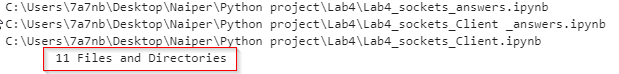

In [ ]:
# Modify this copy of 10c to add your enhancement
import os

files = os.listdir()
for fname in files:
    print(os.path.abspath(fname))

---

**Enhancement 16.2: Labelling files and directories**

Extend the code to label which items are files and which are directories.    
Let's do this linux-style by adding a prefix character, using ```–``` for a file, or ```d``` for a directory.    
When you are done, the output should now be similar to the following:

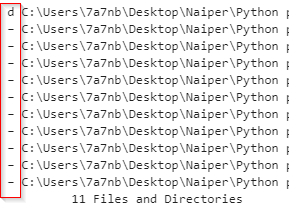

In [ ]:
# copy and paste code from enhancement 16.1 here 
# then add code for enhancement 16.2


---

**Enhancement 16.3: Add file sizes and MAC times**


The **os.path.getsize()** function returns the size of a file/directory. (But note that this value is meaningless for directories).     
Try the following command:

In [ ]:
print(os.path.getsize(r"modules.txt"))

(This file should exist, but if it doesn't, just replace the argument with the full path to any file that you know exists)


Q16.3.a: What unit does os.path.getsize() use?  (Hint: look up the Python docs for os.stat - google is your friend)

---

os.path also has methods to get the MAC (modified, accessed, created) timestamps for directories and files. For example, the **os.path.getctime()** function gets the **c**reated timestamp.   

Try:

In [ ]:
timestamp = os.path.getctime(r"modules.txt")
print(timestamp)

Q16.3.b: What is the creation timestamp for the file? 

Q16.3.c: In what units is the timestamp returned? (Hint: look up the Python docs for os.stat - google is your friend)

---

Two similar functions, os.path.get**m**time() and os.path.get**a**time() can be used to show **m**odified and **a**ccessed time stamps respectively. As different file systems store MAC (modified, accessed, created) times differently, the results you get and the format will depend on the underlying file system. If your course includes a digital forensics module, you will learn more about this in that module. 

The timestamps can be changed into a readable date and time using the datetime module.

The next cell shows an example:

In [ ]:
import datetime

print(datetime.datetime.fromtimestamp(timestamp))

---

Using the snippets above as ideas, extend your code so that it also displays the size and last modified date and time for each item in the listing.  
Format the size to 8d (we covered this in an earlier lab) so that it's aligned neatly.   

When you are done, your output should look similar to this:

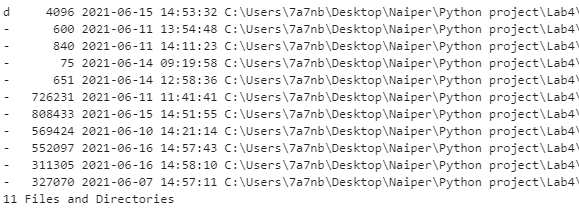


In [ ]:
# copy and paste code from enhancement 16.2 here 
# then add code for enhancement 16.3


---


## 17. (Optional) Writing the directory listing to a file

---
Let's combine some of the exercises above.   
You are going to modify your code from exercise 16, enhancement 16.3, so copy and paste your code in the cell below.  

In [ ]:
# copy and paste code from enhancement 16.3 here 
# then change as described below


**Change the code so it writes a log file** instead of printing the info to the screen.

The main change you need to make to your existing code is to replace print statements with logfile.write statements.   
The main difference between these two is that print automatically adds a new line, while write() does not.   

So, the line 
~~~python
print(f"{size:8d} {time} {os.path.abspath(path)}")
~~~

Should be changed to:
~~~python
logfile.write(f"{size:8d} {time} {os.path.abspath(path)}\n")
~~~
As we are opening and writing files, we need to ensure that the file is always closed in the end, even if an error occurs. Therefore you should wrap your code in a try: block.

Your new code might look like this:

~~~python

try:
    logfile = open(r"c:\temp\lslog.txt", "w")

    # your exsisting code here, but change print statements to 
    # logfile.write() statements

except IOError as err:
    print(f"File Error:  {IOError}")
finally:
    if "logfile" in locals():
        logfile.close()
~~~

---

Q17.1: Why do we have a finally: block in the above example solution? 

Q17.2: If your code doesn't already use "with open" re-write it so that it does. Why is it a good idea to use "with open"?